In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)

In [3]:
jan2019 = pd.read_parquet('C:/Users/Manhab Zafar/Downloads/yellow_tripdata_2019-01.parquet')
jan2020 = pd.read_parquet('C:/Users/Manhab Zafar/Downloads/yellow_tripdata_2020-01.parquet')
apr2020 = pd.read_parquet('C:/Users/Manhab Zafar/Downloads/yellow_tripdata_2020-04.parquet')
jan2022 = pd.read_parquet('C:/Users/Manhab Zafar/Downloads/yellow_tripdata_2022-01.parquet')

print("Jan 2019:", jan2019.shape)
print("Jan 2020:", jan2020.shape)
print("Apr 2020:", apr2020.shape)
print("Jan 2022:", jan2022.shape)

Jan 2019: (7696617, 19)
Jan 2020: (6405008, 19)
Apr 2020: (238073, 19)
Jan 2022: (2463931, 19)


In [4]:
print(jan2019.columns.tolist())
print(jan2019.dtypes)
jan2019.head()

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    f

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN,None
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN,None
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN,None
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN,None
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN,None


In [5]:
def summarize(df, label):
    print(f"\n===== {label} =====")
    print(f"Rows: {len(df)}")
    print(f"Avg trip distance: {df['trip_distance'].mean():.2f}")
    print(f"Avg fare amount:   {df['fare_amount'].mean():.2f}")
    print(f"Avg trip duration: {((df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60).mean():.2f} mins")

summarize(jan2019, "Jan 2019 (Baseline)")
summarize(jan2020, "Jan 2020 (Pre-COVID)")
summarize(apr2020, "Apr 2020 (Peak COVID)")
summarize(jan2022, "Jan 2022 (Recovery)")


===== Jan 2019 (Baseline) =====
Rows: 7696617
Avg trip distance: 2.83
Avg fare amount:   12.53
Avg trip duration: 16.55 mins

===== Jan 2020 (Pre-COVID) =====
Rows: 6405008
Avg trip distance: 2.93
Avg fare amount:   12.69
Avg trip duration: 15.95 mins

===== Apr 2020 (Peak COVID) =====
Rows: 238073
Avg trip distance: 4.04
Avg fare amount:   11.67
Avg trip duration: 11.27 mins

===== Jan 2022 (Recovery) =====
Rows: 2463931
Avg trip distance: 5.37
Avg fare amount:   12.95
Avg trip duration: 14.21 mins


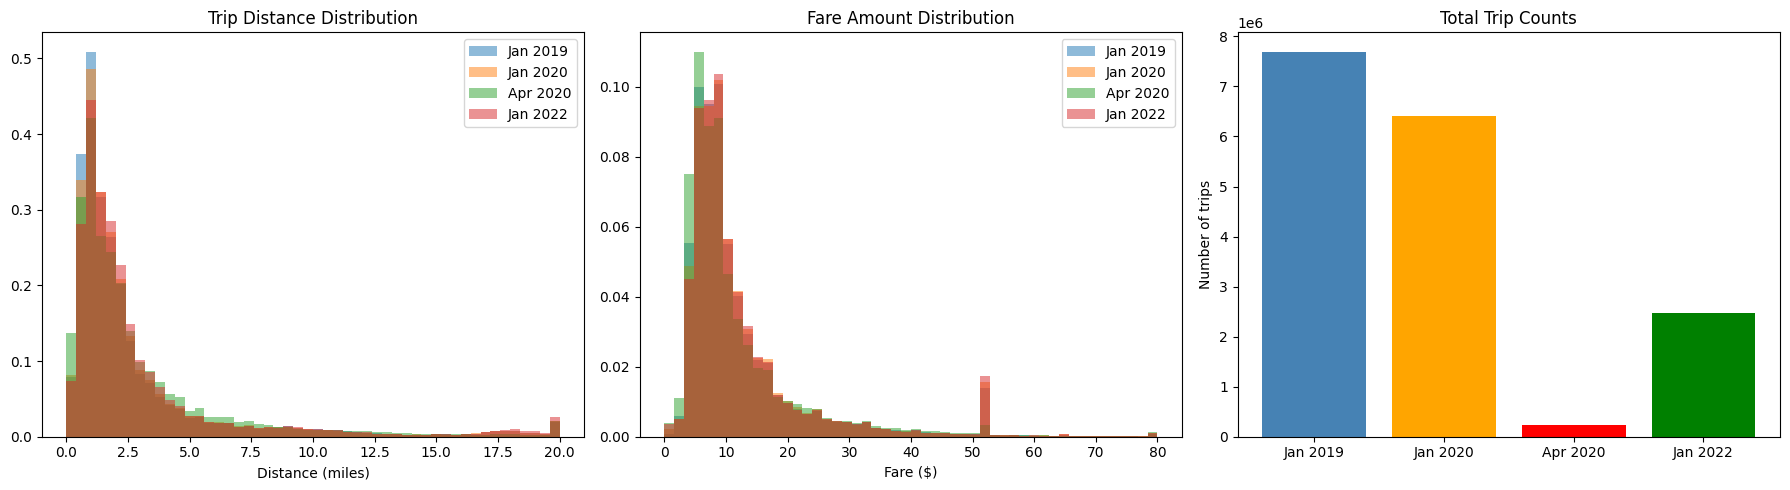

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = {
    'Jan 2019': jan2019,
    'Jan 2020': jan2020,
    'Apr 2020': apr2020,
    'Jan 2022': jan2022
}

# Trip distance distribution
for label, df in datasets.items():
    axes[0].hist(df['trip_distance'].clip(0, 20), bins=50, alpha=0.5, label=label, density=True)
axes[0].set_title('Trip Distance Distribution')
axes[0].set_xlabel('Distance (miles)')
axes[0].legend()

# Fare amount distribution
for label, df in datasets.items():
    axes[1].hist(df['fare_amount'].clip(0, 80), bins=50, alpha=0.5, label=label, density=True)
axes[1].set_title('Fare Amount Distribution')
axes[1].set_xlabel('Fare ($)')
axes[1].legend()

# Trip counts
counts = {label: len(df) for label, df in datasets.items()}
axes[2].bar(counts.keys(), counts.values(), color=['steelblue','orange','red','green'])
axes[2].set_title('Total Trip Counts')
axes[2].set_ylabel('Number of trips')

plt.tight_layout()
plt.savefig('data/processed/eda_overview.png', dpi=150)
plt.show()

In [8]:
def preprocess(df):
    df = df.copy()
    
    # Calculate trip duration in minutes
    df['duration_minutes'] = (
        df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60
    
    # Select features we'll use for the model
    features = ['trip_distance', 'fare_amount', 'PULocationID', 
                'DOLocationID', 'passenger_count']
    target = 'duration_minutes'
    
    df = df[features + [target]].dropna()
    
    # Remove outliers
    df = df[
        (df['duration_minutes'] > 1) & (df['duration_minutes'] < 120) &
        (df['trip_distance'] > 0) & (df['trip_distance'] < 50) &
        (df['fare_amount'] > 0) & (df['fare_amount'] < 200)
    ]
    
    return df

jan2019_clean = preprocess(jan2019)
jan2020_clean = preprocess(jan2020)
apr2020_clean = preprocess(apr2020)
jan2022_clean = preprocess(jan2022)

print("Cleaned shapes:")
print(f"Jan 2019: {jan2019_clean.shape}")
print(f"Jan 2020: {jan2020_clean.shape}")
print(f"Apr 2020: {apr2020_clean.shape}")
print(f"Jan 2022: {jan2022_clean.shape}")

# Save cleaned data
jan2019_clean.to_parquet('data/processed/jan2019_clean.parquet')
jan2020_clean.to_parquet('data/processed/jan2020_clean.parquet')
apr2020_clean.to_parquet('data/processed/apr2020_clean.parquet')
jan2022_clean.to_parquet('data/processed/jan2022_clean.parquet')

print("\nAll cleaned files saved to data/processed/")

Cleaned shapes:
Jan 2019: (7554885, 6)
Jan 2020: (6215313, 6)
Apr 2020: (209593, 6)
Jan 2022: (2341364, 6)

All cleaned files saved to data/processed/
